In [43]:
import os
import random
import warnings
from pathlib import Path
from itertools import combinations

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
warnings.filterwarnings("ignore")


## Inisiasi dataset

In [44]:
DATASET_ROOT = Path(r"d:\Semester 6\Capstone")
DATA_YAML_PATH = DATASET_ROOT / "data.yaml"

# Nama kelas sesuai data.yaml
CLASS_NAMES = [
    "Bis mini", "Manusia", "Mobil", "Motor",
    "Truk berat", "Truk menengah", "Truk ringan", "bus"
]

# setting warna setiap kelas
# 0 = bis mini
# 1 = manusia
# 2 = Mobil
# 3 = motor
# 4 = truk berat
# 5 = truk ringan 
# 6 = truk menengah
# 7 = bus

CLASS_COLORS_BGR = {
    0: (255, 100, 50),  
    1: (50, 255, 50),   
    2: (0, 0, 255),       
    3: (0, 255, 255),     
    4: (255, 0, 150),     
    5: (255, 165, 0),     
    6: (200, 200, 0),     
    7: (150, 50, 255),    
}
CLASS_COLORS_HEX = {
    0: "#32C8FF",   
    1: "#32FF32",  
    2: "#FF0000",   
    3: "#FFFF00",   
    4: "#9600FF",   
    5: "#00A5FF",   
    6: "#00C8C8",   
    7: "#FF32C8",   
}

# Jumlah gambar sampel untuk visualisasi box
NUM_SAMPLE_IMAGES = 10

# Set ukuran figure
FIG_SIZE = (14, 8)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Style matplotlib
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")


def parse_yolo_line(line):
    parts = line.strip().split()
    if len(parts) < 5:
        return None
    try:
        class_id = int(parts[0])

        if len(parts) == 5:
            # Format bbox standar YOLO
            x_center = float(parts[1])
            y_center = float(parts[2])
            width = float(parts[3])
            height = float(parts[4])
        else:
            # Format polygon segmentation -> convert ke bbox
            coords = [float(v) for v in parts[1:]]
            xs = coords[0::2]  # Semua x (indeks genap)
            ys = coords[1::2]  # Semua y (indeks ganjil)

            x_min = min(xs)
            x_max = max(xs)
            y_min = min(ys)
            y_max = max(ys)

            x_center = (x_min + x_max) / 2
            y_center = (y_min + y_max) / 2
            width = x_max - x_min
            height = y_max - y_min

        return (class_id, x_center, y_center, width, height)

    except (ValueError, IndexError):
        return None
    
def load_dataset(splits=None):
    if splits is None:
        splits = ["train", "valid", "test"]

    all_records = []
    stats = {
        "total_images": 0,
        "total_labels": 0,
        "empty_labels": 0,
        "images_without_labels": 0,
        "parse_errors": 0,
        "total_annotations": 0,
    }

    # print("=" * 65)
    # print("  LOADING DATASET")
    # print("=" * 65)

    for split in splits:
        images_dir = DATASET_ROOT / split / "images"
        labels_dir = DATASET_ROOT / split / "labels"

        if not images_dir.exists():
            print(f"  [WARNING] Folder tidak ditemukan: {images_dir}")
            continue

        # Ambil semua file gambar
        image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}
        image_files = [
            f for f in os.listdir(images_dir)
            if Path(f).suffix.lower() in image_extensions
        ]
        stats["total_images"] += len(image_files)

        print(f"\n  [{split.upper()}] Memproses {len(image_files)} gambar...")

        for img_file in image_files:
            img_path = images_dir / img_file
            label_file = Path(img_file).stem + ".txt"
            label_path = labels_dir / label_file

            # Cek apakah file label ada
            if not label_path.exists():
                stats["images_without_labels"] += 1
                continue

            stats["total_labels"] += 1

            # Baca file label
            try:
                with open(label_path, "r") as f:
                    lines = f.readlines()
            except Exception as e:
                print(f"    [ERROR] Gagal membaca {label_path}: {e}")
                stats["parse_errors"] += 1
                continue

            # Handle label kosong
            lines = [l.strip() for l in lines if l.strip()]
            if len(lines) == 0:
                stats["empty_labels"] += 1
                continue

            # Parse setiap baris anotasi
            for line in lines:
                parsed = parse_yolo_line(line)
                if parsed is None:
                    stats["parse_errors"] += 1
                    continue

                class_id, xc, yc, w, h = parsed

                # Validasi class_id
                if class_id < 0 or class_id >= len(CLASS_NAMES):
                    stats["parse_errors"] += 1
                    continue

                all_records.append({
                    "split": split,
                    "image_file": img_file,
                    "image_path": str(img_path),
                    "label_path": str(label_path),
                    "class_id": class_id,
                    "class_name": CLASS_NAMES[class_id],
                    "x_center": xc,
                    "y_center": yc,
                    "bbox_width": w,
                    "bbox_height": h,
                    "bbox_area": w * h,
                })
                stats["total_annotations"] += 1

    # Buat DataFrame
    df = pd.DataFrame(all_records)

    # Tampilkan ringkasan loading
    # print(f"\n{'─' * 65}")
    # print(f"  RINGKASAN LOADING:")
    # print(f"{'─' * 65}")
    print(f"  Total gambar          : {stats['total_images']}")
    print(f"  Total file label      : {stats['total_labels']}")
    print(f"  Total anotasi (bbox)  : {stats['total_annotations']}")
    print(f"  Label kosong          : {stats['empty_labels']}")
    print(f"  Gambar tanpa label    : {stats['images_without_labels']}")
    print(f"  Error parsing         : {stats['parse_errors']}")

    if not df.empty:
        # Statistik per split
        print(f"\n  Per Split:")
        for split in splits:
            split_df = df[df["split"] == split]
            n_images = split_df["image_file"].nunique()
            n_annots = len(split_df)
            avg_per_img = n_annots / max(n_images, 1)
            print(f"    {split:6s} → {n_images:4d} gambar, "
                  f"{n_annots:5d} anotasi "
                  f"(rata-rata {avg_per_img:.1f} objek/gambar)")

    # print(f"{'=' * 65}\n")
    return df

## EDA

In [45]:
def visualize_bounding_boxes(df, split="train", num_images=NUM_SAMPLE_IMAGES):
    """
    Menampilkan gambar sampel acak beserta bounding box-nya.

    Setiap kelas divisualisasikan dengan warna yang berbeda untuk
    memudahkan identifikasi visual. Label kelas ditampilkan di atas
    setiap bounding box.

    Args:
        df        : DataFrame hasil load_dataset()
        split     : Split yang akan divisualisasikan
        num_images: Jumlah gambar yang ditampilkan
    """
    print("=" * 65)
    print(f"  VISUALISASI BOUNDING BOX ({split.upper()})")
    print("=" * 65)

    split_df = df[df["split"] == split]
    if split_df.empty:
        print(f"  [WARNING] Tidak ada data untuk split '{split}'")
        return

    # Pilih gambar secara acak
    unique_images = split_df["image_file"].unique()
    num_to_show = min(num_images, len(unique_images))
    selected = random.sample(list(unique_images), num_to_show)

    # Layout grid
    cols = min(5, num_to_show)
    rows = (num_to_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    if rows == 1 and cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for idx, img_name in enumerate(selected):
        ax = axes[idx]

        # Load gambar
        img_row = split_df[split_df["image_file"] == img_name].iloc[0]
        img = cv2.imread(img_row["image_path"])

        if img is None:
            ax.set_title(f"Error: {img_name[:20]}...")
            ax.axis("off")
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_h, img_w = img.shape[:2]

        # Gambar bbox untuk setiap anotasi pada gambar ini
        img_annotations = split_df[split_df["image_file"] == img_name]
        ax.imshow(img_rgb)

        for _, row in img_annotations.iterrows():
            # Konversi dari normalisasi ke piksel
            xc = row["x_center"] * img_w
            yc = row["y_center"] * img_h
            w = row["bbox_width"] * img_w
            h = row["bbox_height"] * img_h

            x1 = xc - w / 2
            y1 = yc - h / 2

            cid = row["class_id"]
            color = CLASS_COLORS_HEX.get(cid, "#FFFFFF")

            # Gambar rectangle
            rect = patches.Rectangle(
                (x1, y1), w, h,
                linewidth=2, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)

            # Label kelas
            ax.text(
                x1, y1 - 4, row["class_name"],
                color="white", fontsize=6, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor=color, alpha=0.8)
            )

        # Info jumlah objek
        n_obj = len(img_annotations)
        ax.set_title(f"{n_obj} objek", fontsize=9, fontweight="bold")
        ax.axis("off")

    # Sembunyikan axis kosong
    for idx in range(num_to_show, len(axes)):
        axes[idx].axis("off")

    # Legenda warna kelas
    legend_handles = [
        patches.Patch(color=CLASS_COLORS_HEX[i], label=name)
        for i, name in enumerate(CLASS_NAMES)
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=4,
        fontsize=9,
        frameon=True,
        title="Kelas",
        title_fontsize=10,
    )

    fig.suptitle(
        f"Visualisasi Bounding Box — {split.upper()} ({num_to_show} sampel acak)",
        fontsize=14, fontweight="bold", y=1.02
    )
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig(str(DATASET_ROOT / f"eda_bbox_samples_{split}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  → Disimpan: eda_bbox_samples_{split}.png\n")

In [46]:
def class_distribution(df):
    print("=" * 65)
    print("  DISTRIBUSI KELAS (CLASS DISTRIBUTION)")
    print("=" * 65)

    # --- Statistik numerik ---
    class_counts = df["class_name"].value_counts().sort_index()
    total = class_counts.sum()

    print(f"\n  {'Kelas':<16s} {'Jumlah':>8s} {'Persentase':>10s}")
    print(f"  {'─' * 36}")
    for name, count in class_counts.items():
        pct = count / total * 100
        print(f"  {name:<16s} {count:>8d} {pct:>9.1f}%")
    print(f"  {'─' * 36}")
    print(f"  {'TOTAL':<16s} {total:>8d} {'100.0%':>10s}")

    # Rasio imbalance
    max_class = class_counts.idxmax()
    min_class = class_counts.idxmin()
    imbalance_ratio = class_counts.max() / class_counts.min()
    print(f"\n  Kelas terbanyak   : {max_class} ({class_counts.max()})")
    print(f"  Kelas tersedikit  : {min_class} ({class_counts.min()})")
    print(f"  Rasio imbalance   : {imbalance_ratio:.1f}x")

    if imbalance_ratio > 10:
        print(f"  ⚠️  PERINGATAN: Imbalance sangat tinggi! "
              f"Pertimbangkan oversampling / class weights.")
    elif imbalance_ratio > 5:
        print(f"  ⚠️  Imbalance moderat. Monitor performa per-kelas saat training.")

    # --- Visualisasi ---
    fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)

    # Bar chart - Total
    colors = [CLASS_COLORS_HEX[i] for i in range(len(CLASS_NAMES))
              if CLASS_NAMES[i] in class_counts.index]
    class_counts_sorted = class_counts.sort_values(ascending=True)
    colors_sorted = [CLASS_COLORS_HEX[CLASS_NAMES.index(name)]
                     for name in class_counts_sorted.index]

    bars = axes[0].barh(class_counts_sorted.index, class_counts_sorted.values,
                        color=colors_sorted, edgecolor="white", linewidth=0.5)
    axes[0].set_xlabel("Jumlah Anotasi", fontsize=11)
    axes[0].set_title("Distribusi Kelas (Total)", fontsize=13, fontweight="bold")

    # Tambahkan label angka di setiap bar
    for bar, val in zip(bars, class_counts_sorted.values):
        axes[0].text(val + total * 0.005, bar.get_y() + bar.get_height() / 2,
                     f"{val:,}", va="center", fontsize=9, fontweight="bold")

    # Bar chart - Per Split (stacked)
    split_class = df.groupby(["split", "class_name"]).size().unstack(fill_value=0)
    split_class = split_class.reindex(columns=CLASS_NAMES, fill_value=0)
    split_colors = [CLASS_COLORS_HEX[i] for i in range(len(CLASS_NAMES))]

    split_class.plot(
        kind="bar", stacked=True, ax=axes[1],
        color=split_colors, edgecolor="white", linewidth=0.5
    )
    axes[1].set_title("Distribusi Kelas per Split", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Split", fontsize=11)
    axes[1].set_ylabel("Jumlah Anotasi", fontsize=11)
    axes[1].legend(fontsize=8, title="Kelas", title_fontsize=9)
    axes[1].tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.savefig(str(DATASET_ROOT / "eda_class_distribution.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Disimpan: eda_class_distribution.png\n")

In [47]:
def bbox_size_distribution(df):
    """
    Menganalisis distribusi ukuran bounding box (width, height, area).

    Penting untuk:
      - Menentukan anchor box yang optimal
      - Mengidentifikasi objek kecil yang mungkin sulit dideteksi
      - Memilih resolusi training yang tepat

    Kategori ukuran (berdasarkan area normalisasi):
      - Sangat kecil : area < 0.001 (< ~28px di 880px)
      - Kecil        : 0.001 ≤ area < 0.01
      - Sedang       : 0.01 ≤ area < 0.05
      - Besar        : area ≥ 0.05

    Args:
        df: DataFrame hasil load_dataset()
    """
    print("=" * 65)
    print("  DISTRIBUSI UKURAN BOUNDING BOX")
    print("=" * 65)

    # --- Statistik per kelas ---
    print(f"\n  {'Kelas':<16s} {'Width (avg)':<12s} {'Height (avg)':<12s} "
          f"{'Area (avg)':<12s}")
    print(f"  {'─' * 52}")

    for name in CLASS_NAMES:
        cls_df = df[df["class_name"] == name]
        if cls_df.empty:
            continue
        avg_w = cls_df["bbox_width"].mean()
        avg_h = cls_df["bbox_height"].mean()
        avg_a = cls_df["bbox_area"].mean()
        print(f"  {name:<16s} {avg_w:<12.4f} {avg_h:<12.4f} {avg_a:<12.6f}")

    # --- Kategorisasi ukuran objek ---
    bins = [0, 0.001, 0.01, 0.05, 1.0]
    labels_size = ["Sangat Kecil", "Kecil", "Sedang", "Besar"]
    df["size_category"] = pd.cut(df["bbox_area"], bins=bins, labels=labels_size)

    size_dist = df["size_category"].value_counts().sort_index()
    print(f"\n  Distribusi kategori ukuran:")
    for cat, cnt in size_dist.items():
        pct = cnt / len(df) * 100
        print(f"    {cat:<14s}: {cnt:6d} ({pct:5.1f}%)")

    pct_small = (df["bbox_area"] < 0.01).sum() / len(df) * 100
    if pct_small > 50:
        print(f"\n  ⚠️  {pct_small:.1f}% objek berukuran kecil/sangat kecil!")
        print(f"      → Pertimbangkan resolusi training yang lebih tinggi (640+)")
        print(f"      → Gunakan mosaic augmentation untuk objek kecil")

    # --- Visualisasi ---
    fig, axes = plt.subplots(2, 2, figsize=FIG_SIZE)

    # 1. Histogram Width
    for i, name in enumerate(CLASS_NAMES):
        cls_df = df[df["class_name"] == name]
        if not cls_df.empty:
            axes[0, 0].hist(
                cls_df["bbox_width"], bins=50, alpha=0.6,
                label=name, color=CLASS_COLORS_HEX[i]
            )
    axes[0, 0].set_title("Distribusi Width Bbox", fontweight="bold")
    axes[0, 0].set_xlabel("Width (normalisasi)")
    axes[0, 0].set_ylabel("Frekuensi")
    axes[0, 0].legend(fontsize=7)

    # 2. Histogram Height
    for i, name in enumerate(CLASS_NAMES):
        cls_df = df[df["class_name"] == name]
        if not cls_df.empty:
            axes[0, 1].hist(
                cls_df["bbox_height"], bins=50, alpha=0.6,
                label=name, color=CLASS_COLORS_HEX[i]
            )
    axes[0, 1].set_title("Distribusi Height Bbox", fontweight="bold")
    axes[0, 1].set_xlabel("Height (normalisasi)")
    axes[0, 1].set_ylabel("Frekuensi")
    axes[0, 1].legend(fontsize=7)

    # 3. Scatter Width vs Height per kelas
    for i, name in enumerate(CLASS_NAMES):
        cls_df = df[df["class_name"] == name]
        if not cls_df.empty:
            axes[1, 0].scatter(
                cls_df["bbox_width"], cls_df["bbox_height"],
                alpha=0.3, s=10, label=name, color=CLASS_COLORS_HEX[i]
            )
    axes[1, 0].set_title("Width vs Height per Kelas", fontweight="bold")
    axes[1, 0].set_xlabel("Width (normalisasi)")
    axes[1, 0].set_ylabel("Height (normalisasi)")
    axes[1, 0].legend(fontsize=7)
    axes[1, 0].set_xlim(0, max(df["bbox_width"].quantile(0.99), 0.5))
    axes[1, 0].set_ylim(0, max(df["bbox_height"].quantile(0.99), 0.5))

    # 4. Distribusi Area (log scale)
    for i, name in enumerate(CLASS_NAMES):
        cls_df = df[df["class_name"] == name]
        if not cls_df.empty:
            areas = cls_df["bbox_area"]
            areas = areas[areas > 0]  # Hindari log(0)
            axes[1, 1].hist(
                np.log10(areas), bins=50, alpha=0.6,
                label=name, color=CLASS_COLORS_HEX[i]
            )
    axes[1, 1].set_title("Distribusi Area Bbox (log₁₀)", fontweight="bold")
    axes[1, 1].set_xlabel("log₁₀(Area)")
    axes[1, 1].set_ylabel("Frekuensi")
    axes[1, 1].legend(fontsize=7)

    # Tambahkan garis batas kategori ukuran
    for threshold, label in zip([-3, -2, -1.3], ["Sangat Kecil", "Kecil", "Sedang"]):
        axes[1, 1].axvline(x=threshold, color="red", linestyle="--",
                           alpha=0.5, linewidth=1)
        axes[1, 1].text(threshold + 0.02, axes[1, 1].get_ylim()[1] * 0.9,
                        label, fontsize=7, color="red", rotation=90, va="top")

    plt.suptitle("Analisis Ukuran Bounding Box",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(str(DATASET_ROOT / "eda_bbox_size_distribution.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  → Disimpan: eda_bbox_size_distribution.png\n")

    # Kembalikan kolom size_category (sudah ditambahkan ke df secara in-place)
    return df


In [48]:
def bbox_heatmap(df, resolution=100):
    """
    Membuat heatmap yang menunjukkan distribusi spasial objek dalam gambar.

    Berguna untuk:
      - Mengidentifikasi area gambar yang paling banyak berisi objek
      - Mendeteksi bias posisi (misalnya objek selalu di bagian bawah)
      - Merancang strategi cropping / augmentasi

    Args:
        df         : DataFrame hasil load_dataset()
        resolution : Resolusi grid heatmap (NxN)
    """
    print("=" * 65)
    print("  HEATMAP LOKASI OBJEK")
    print("=" * 65)

    # Buat heatmap untuk semua kelas dan per kelas
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))

    # --- Heatmap gabungan (semua kelas) ---
    # Plot di posisi terakhir, tapi buat dulu
    heatmap_all = np.zeros((resolution, resolution), dtype=np.float64)

    for _, row in df.iterrows():
        xc = row["x_center"]
        yc = row["y_center"]
        w = row["bbox_width"]
        h = row["bbox_height"]

        # Konversi ke grid
        x_min = max(0, int((xc - w / 2) * resolution))
        x_max = min(resolution, int((xc + w / 2) * resolution))
        y_min = max(0, int((yc - h / 2) * resolution))
        y_max = min(resolution, int((yc + h / 2) * resolution))

        heatmap_all[y_min:y_max, x_min:x_max] += 1

    # --- Heatmap per kelas ---
    for idx, name in enumerate(CLASS_NAMES):
        row_idx = idx // 4
        col_idx = idx % 4
        ax = axes[row_idx, col_idx]

        cls_df = df[df["class_name"] == name]
        heatmap = np.zeros((resolution, resolution), dtype=np.float64)

        for _, row in cls_df.iterrows():
            xc = row["x_center"]
            yc = row["y_center"]
            w = row["bbox_width"]
            h = row["bbox_height"]

            x_min = max(0, int((xc - w / 2) * resolution))
            x_max = min(resolution, int((xc + w / 2) * resolution))
            y_min = max(0, int((yc - h / 2) * resolution))
            y_max = min(resolution, int((yc + h / 2) * resolution))

            heatmap[y_min:y_max, x_min:x_max] += 1

        # Normalisasi untuk visualisasi
        if heatmap.max() > 0:
            heatmap_norm = heatmap / heatmap.max()
        else:
            heatmap_norm = heatmap

        im = ax.imshow(heatmap_norm, cmap="YlOrRd", aspect="equal",
                       extent=[0, 1, 1, 0])
        ax.set_title(f"{name}\n({len(cls_df)} objek)", fontsize=10,
                     fontweight="bold", color=CLASS_COLORS_HEX[idx])
        ax.set_xlabel("X", fontsize=8)
        ax.set_ylabel("Y", fontsize=8)
        ax.tick_params(labelsize=7)

    plt.suptitle("Heatmap Lokasi Objek per Kelas",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(str(DATASET_ROOT / "eda_bbox_heatmap_per_class.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  → Disimpan: eda_bbox_heatmap_per_class.png")

    # --- Heatmap gabungan besar ---
    fig2, ax2 = plt.subplots(1, 1, figsize=(8, 8))
    if heatmap_all.max() > 0:
        heatmap_all_norm = heatmap_all / heatmap_all.max()
    else:
        heatmap_all_norm = heatmap_all

    im2 = ax2.imshow(heatmap_all_norm, cmap="inferno", aspect="equal",
                     extent=[0, 1, 1, 0])
    ax2.set_title("Heatmap Lokasi Objek (Semua Kelas)",
                  fontsize=14, fontweight="bold")
    ax2.set_xlabel("Posisi X (normalisasi)", fontsize=11)
    ax2.set_ylabel("Posisi Y (normalisasi)", fontsize=11)
    plt.colorbar(im2, ax=ax2, label="Densitas (normalisasi)")

    plt.tight_layout()
    plt.savefig(str(DATASET_ROOT / "eda_bbox_heatmap_all.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  → Disimpan: eda_bbox_heatmap_all.png")

    # Analisis posisi
    center_x_mean = df["x_center"].mean()
    center_y_mean = df["y_center"].mean()
    print(f"\n  Rata-rata posisi center X: {center_x_mean:.3f} "
          f"({'kiri' if center_x_mean < 0.45 else 'tengah' if center_x_mean < 0.55 else 'kanan'})")
    print(f"  Rata-rata posisi center Y: {center_y_mean:.3f} "
          f"({'atas' if center_y_mean < 0.45 else 'tengah' if center_y_mean < 0.55 else 'bawah'})")
    print()


In [49]:
def compute_iou(box1, box2):
    """
    Menghitung Intersection over Union (IoU) antara dua bounding box.

    Args:
        box1, box2: tuple (x_center, y_center, width, height) dalam normalisasi

    Returns:
        float: Nilai IoU (0.0 - 1.0)
    """
    # Konversi dari center format ke corner format
    x1_min = box1[0] - box1[2] / 2
    y1_min = box1[1] - box1[3] / 2
    x1_max = box1[0] + box1[2] / 2
    y1_max = box1[1] + box1[3] / 2

    x2_min = box2[0] - box2[2] / 2
    y2_min = box2[1] - box2[3] / 2
    x2_max = box2[0] + box2[2] / 2
    y2_max = box2[1] + box2[3] / 2

    # Area interseksi
    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)

    inter_w = max(0, inter_x_max - inter_x_min)
    inter_h = max(0, inter_y_max - inter_y_min)
    inter_area = inter_w * inter_h

    # Area union
    area1 = box1[2] * box1[3]
    area2 = box2[2] * box2[3]
    union_area = area1 + area2 - inter_area

    if union_area <= 0:
        return 0.0

    return inter_area / union_area



In [50]:
def overlap_analysis(df, max_images=200):
    """
    Menganalisis overlap (IoU) antar bounding box dalam satu gambar.

    Penting untuk kasus traffic padat karena:
      - Kendaraan sering saling menutupi (oklusi)
      - Overlap tinggi bisa menyebabkan masalah pada NMS
      - Membantu menentukan threshold IoU untuk NMS

    Args:
        df         : DataFrame hasil load_dataset()
        max_images : Batas jumlah gambar untuk analisis (untuk efisiensi)
    """
    print("=" * 65)
    print("  OVERLAP ANALYSIS (IoU)")
    print("=" * 65)

    all_ious = []           # Semua nilai IoU
    per_image_avg = []      # Rata-rata IoU per gambar
    high_overlap_count = 0  # Jumlah pasangan dengan IoU > 0.5

    # Group by gambar
    grouped = df.groupby(["split", "image_file"])
    images_analyzed = 0

    for (split, img_name), group in grouped:
        if images_analyzed >= max_images:
            break

        if len(group) < 2:
            continue

        images_analyzed += 1

        # Ambil semua bbox
        boxes = [
            (row["x_center"], row["y_center"], row["bbox_width"], row["bbox_height"])
            for _, row in group.iterrows()
        ]

        # Hitung IoU untuk setiap pasangan bbox
        image_ious = []
        for i, j in combinations(range(len(boxes)), 2):
            iou = compute_iou(boxes[i], boxes[j])
            if iou > 0:
                all_ious.append(iou)
                image_ious.append(iou)
            if iou > 0.5:
                high_overlap_count += 1

        if image_ious:
            per_image_avg.append(np.mean(image_ious))

    # --- Statistik ---
    print(f"\n  Gambar dianalisis       : {images_analyzed}")
    print(f"  Total pasangan overlap  : {len(all_ious)}")

    if all_ious:
        all_ious_arr = np.array(all_ious)
        print(f"\n  Statistik IoU (hanya pasangan yang overlap > 0):")
        print(f"    Mean IoU              : {all_ious_arr.mean():.4f}")
        print(f"    Median IoU            : {np.median(all_ious_arr):.4f}")
        print(f"    Max IoU               : {all_ious_arr.max():.4f}")
        print(f"    Std IoU               : {all_ious_arr.std():.4f}")

        # Distribusi per range IoU
        ranges = [(0, 0.1), (0.1, 0.3), (0.3, 0.5), (0.5, 0.7), (0.7, 1.0)]
        print(f"\n  Distribusi IoU:")
        for lo, hi in ranges:
            count = ((all_ious_arr >= lo) & (all_ious_arr < hi)).sum()
            pct = count / len(all_ious_arr) * 100
            bar = "█" * int(pct / 2)
            print(f"    [{lo:.1f} - {hi:.1f}): {count:6d} ({pct:5.1f}%) {bar}")

        print(f"\n  Pasangan dengan IoU > 0.5: {high_overlap_count}")
        if high_overlap_count > 0:
            print(f"  ⚠️  Ada {high_overlap_count} pasangan bbox dengan overlap tinggi!")
            print(f"      → Pertimbangkan NMS threshold > 0.5 saat inference")
            print(f"      → Review label yang mungkin duplikat")

        # --- Visualisasi ---
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # 1. Histogram IoU
        axes[0].hist(all_ious_arr, bins=50, color="#FF6B6B", edgecolor="white",
                     alpha=0.8)
        axes[0].axvline(x=np.mean(all_ious_arr), color="navy", linestyle="--",
                        linewidth=2, label=f"Mean: {np.mean(all_ious_arr):.3f}")
        axes[0].axvline(x=0.5, color="red", linestyle="-.",
                        linewidth=2, label="IoU = 0.5 (NMS threshold)")
        axes[0].set_title("Distribusi IoU Antar Bbox\n(dalam satu gambar)",
                          fontweight="bold")
        axes[0].set_xlabel("IoU")
        axes[0].set_ylabel("Frekuensi")
        axes[0].legend(fontsize=9)

        # 2. Rata-rata IoU per gambar
        if per_image_avg:
            axes[1].hist(per_image_avg, bins=40, color="#4ECDC4",
                         edgecolor="white", alpha=0.8)
            axes[1].axvline(x=np.mean(per_image_avg), color="navy",
                            linestyle="--", linewidth=2,
                            label=f"Mean: {np.mean(per_image_avg):.3f}")
            axes[1].set_title("Rata-rata IoU per Gambar", fontweight="bold")
            axes[1].set_xlabel("Rata-rata IoU")
            axes[1].set_ylabel("Jumlah Gambar")
            axes[1].legend(fontsize=9)

        # 3. Jumlah objek vs rata-rata IoU per gambar
        obj_counts = []
        avg_ious_per_img = []
        for (split, img_name), group in grouped:
            n = len(group)
            if n < 2:
                continue
            boxes = [
                (r["x_center"], r["y_center"], r["bbox_width"], r["bbox_height"])
                for _, r in group.iterrows()
            ]
            ious = [compute_iou(boxes[i], boxes[j])
                    for i, j in combinations(range(len(boxes)), 2)
                    if compute_iou(boxes[i], boxes[j]) > 0]
            if ious:
                obj_counts.append(n)
                avg_ious_per_img.append(np.mean(ious))

            if len(obj_counts) >= max_images:
                break

        if obj_counts:
            axes[2].scatter(obj_counts, avg_ious_per_img, alpha=0.4,
                            s=20, color="#A78BFA")
            axes[2].set_title("Jumlah Objek vs Rata-rata IoU", fontweight="bold")
            axes[2].set_xlabel("Jumlah Objek per Gambar")
            axes[2].set_ylabel("Rata-rata IoU")

            # Trend line
            z = np.polyfit(obj_counts, avg_ious_per_img, 1)
            p = np.poly1d(z)
            x_line = np.linspace(min(obj_counts), max(obj_counts), 100)
            axes[2].plot(x_line, p(x_line), "r--", linewidth=2,
                         label=f"Trend (slope={z[0]:.4f})")
            axes[2].legend(fontsize=9)

        plt.suptitle("Analisis Overlap (IoU) Antar Bounding Box",
                     fontsize=14, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.savefig(str(DATASET_ROOT / "eda_overlap_analysis.png"),
                    dpi=150, bbox_inches="tight")
        plt.show()
        print(f"\n  → Disimpan: eda_overlap_analysis.png\n")
    else:
        print(f"\n  Tidak ada overlap yang ditemukan antar bbox.\n")

In [51]:
def additional_statistics(df):
    """
    Statistik tambahan yang berguna untuk perencanaan training.

    Meliputi:
      - Distribusi jumlah objek per gambar
      - Aspek rasio bounding box
      - Korelasi antar fitur bbox
    """
    print("=" * 65)
    print("  STATISTIK TAMBAHAN")
    print("=" * 65)

    # --- Distribusi jumlah objek per gambar ---
    obj_per_image = df.groupby(["split", "image_file"]).size()

    print(f"\n  Jumlah objek per gambar:")
    print(f"    Min        : {obj_per_image.min()}")
    print(f"    Max        : {obj_per_image.max()}")
    print(f"    Mean       : {obj_per_image.mean():.1f}")
    print(f"    Median     : {obj_per_image.median():.1f}")
    print(f"    Std        : {obj_per_image.std():.1f}")

    # --- Aspek rasio ---
    df["aspect_ratio"] = df["bbox_width"] / df["bbox_height"].clip(lower=1e-6)

    print(f"\n  Aspek rasio bbox (width/height):")
    print(f"    Min        : {df['aspect_ratio'].min():.3f}")
    print(f"    Max        : {df['aspect_ratio'].max():.3f}")
    print(f"    Mean       : {df['aspect_ratio'].mean():.3f}")
    print(f"    Median     : {df['aspect_ratio'].median():.3f}")

    # --- Visualisasi ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Distribusi jumlah objek per gambar
    axes[0].hist(obj_per_image, bins=50, color="#6C5CE7",
                 edgecolor="white", alpha=0.8)
    axes[0].axvline(x=obj_per_image.mean(), color="red", linestyle="--",
                    linewidth=2, label=f"Mean: {obj_per_image.mean():.1f}")
    axes[0].set_title("Jumlah Objek per Gambar", fontweight="bold")
    axes[0].set_xlabel("Jumlah Objek")
    axes[0].set_ylabel("Jumlah Gambar")
    axes[0].legend()

    # 2. Aspek rasio per kelas
    for i, name in enumerate(CLASS_NAMES):
        cls_df = df[df["class_name"] == name]
        if not cls_df.empty:
            ar = cls_df["aspect_ratio"]
            # Clip untuk visualisasi yang lebih baik
            ar_clipped = ar.clip(upper=ar.quantile(0.99))
            axes[1].hist(ar_clipped, bins=30, alpha=0.5,
                         label=name, color=CLASS_COLORS_HEX[i])
    axes[1].set_title("Distribusi Aspek Rasio per Kelas", fontweight="bold")
    axes[1].set_xlabel("Aspek Rasio (Width / Height)")
    axes[1].set_ylabel("Frekuensi")
    axes[1].legend(fontsize=7)
    axes[1].axvline(x=1.0, color="gray", linestyle=":", alpha=0.7)

    # 3. Komposisi kelas per gambar (top 20 gambar dengan objek terbanyak)
    top_images = obj_per_image.nlargest(20)
    image_class_comp = []
    for (split, img_name), count in top_images.items():
        img_df = df[(df["split"] == split) & (df["image_file"] == img_name)]
        comp = img_df["class_name"].value_counts().to_dict()
        comp["image"] = img_name[:25] + "..."
        comp["total"] = count
        image_class_comp.append(comp)

    comp_df = pd.DataFrame(image_class_comp).fillna(0)
    comp_df = comp_df.set_index("image")
    existing_classes = [c for c in CLASS_NAMES if c in comp_df.columns]
    comp_colors = [CLASS_COLORS_HEX[CLASS_NAMES.index(c)] for c in existing_classes]

    if existing_classes:
        comp_df[existing_classes].plot(
            kind="barh", stacked=True, ax=axes[2],
            color=comp_colors, edgecolor="white", linewidth=0.5
        )
        axes[2].set_title("Top 20 Gambar (Objek Terbanyak)", fontweight="bold")
        axes[2].set_xlabel("Jumlah Objek")
        axes[2].legend(fontsize=7, title="Kelas")

    plt.suptitle("Statistik Tambahan Dataset",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(str(DATASET_ROOT / "eda_additional_stats.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n  → Disimpan: eda_additional_stats.png\n")


  [TRAIN] Memproses 632 gambar...

  [VALID] Memproses 181 gambar...

  [TEST] Memproses 90 gambar...
  Total gambar          : 903
  Total file label      : 903
  Total anotasi (bbox)  : 14638
  Label kosong          : 60
  Gambar tanpa label    : 0
  Error parsing         : 0

  Per Split:
    train  →  586 gambar, 10058 anotasi (rata-rata 17.2 objek/gambar)
    valid  →  172 gambar,  3188 anotasi (rata-rata 18.5 objek/gambar)
    test   →   85 gambar,  1392 anotasi (rata-rata 16.4 objek/gambar)
  VISUALISASI BOUNDING BOX (TRAIN)


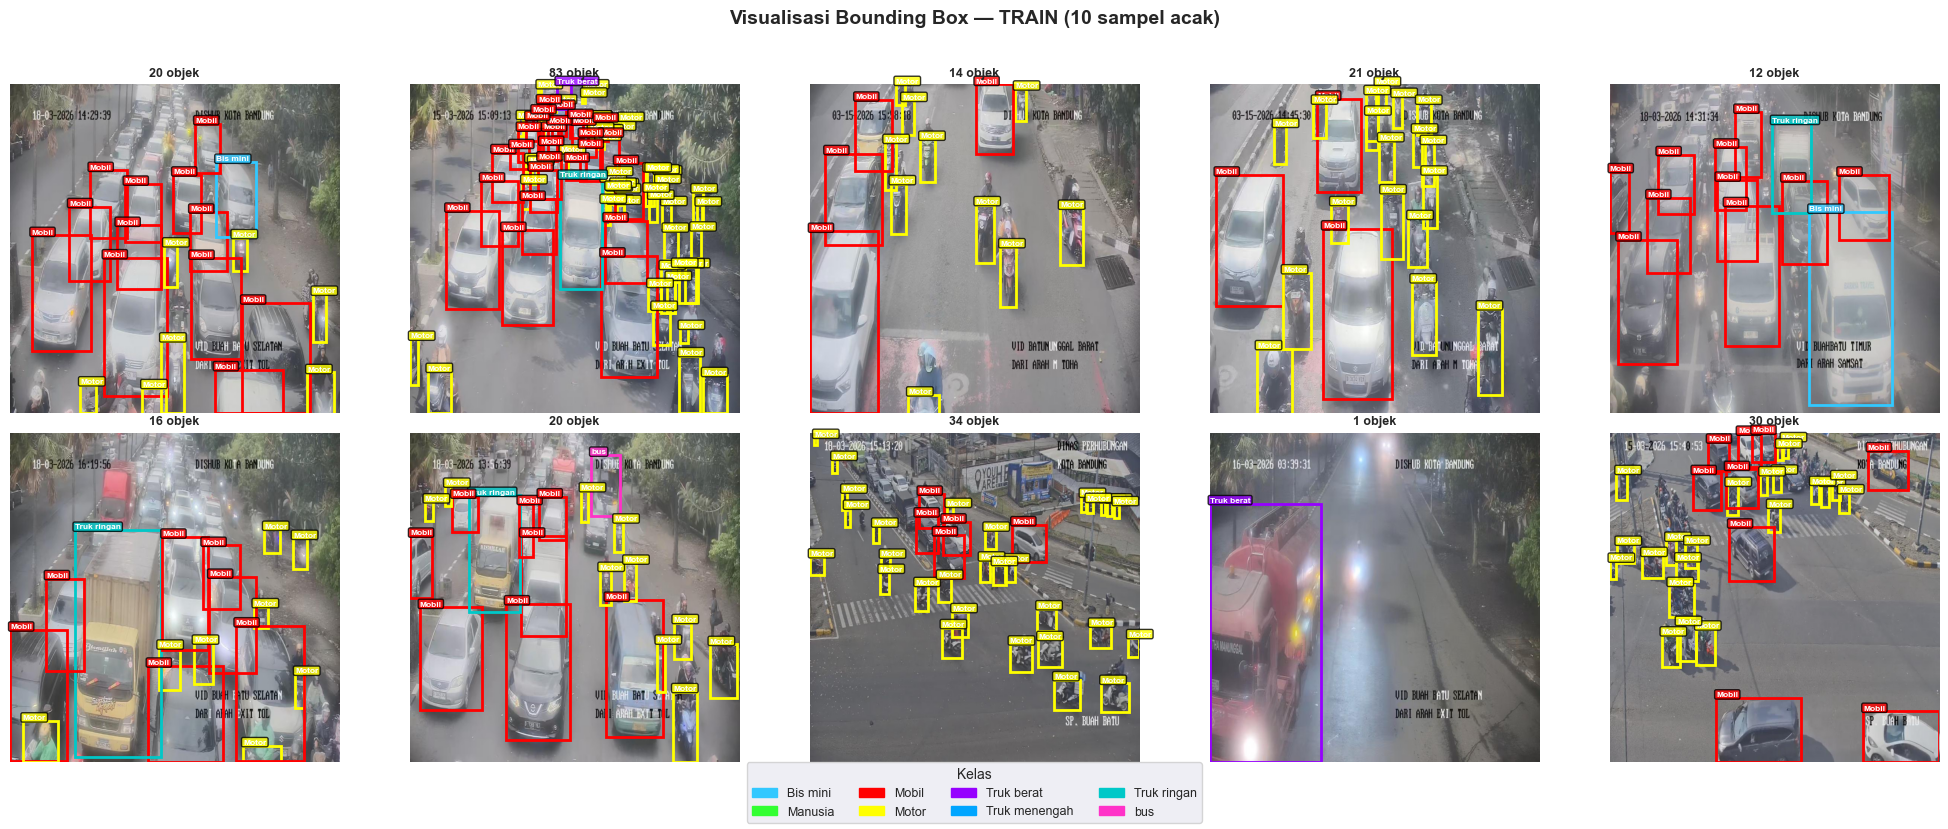

  → Disimpan: eda_bbox_samples_train.png

  DISTRIBUSI KELAS (CLASS DISTRIBUTION)

  Kelas              Jumlah Persentase
  ────────────────────────────────────
  Bis mini               29       0.2%
  Manusia                16       0.1%
  Mobil                4627      31.6%
  Motor                9654      66.0%
  Truk berat            100       0.7%
  Truk menengah          44       0.3%
  Truk ringan           139       0.9%
  bus                    29       0.2%
  ────────────────────────────────────
  TOTAL               14638     100.0%

  Kelas terbanyak   : Motor (9654)
  Kelas tersedikit  : Manusia (16)
  Rasio imbalance   : 603.4x
  ⚠️  PERINGATAN: Imbalance sangat tinggi! Pertimbangkan oversampling / class weights.


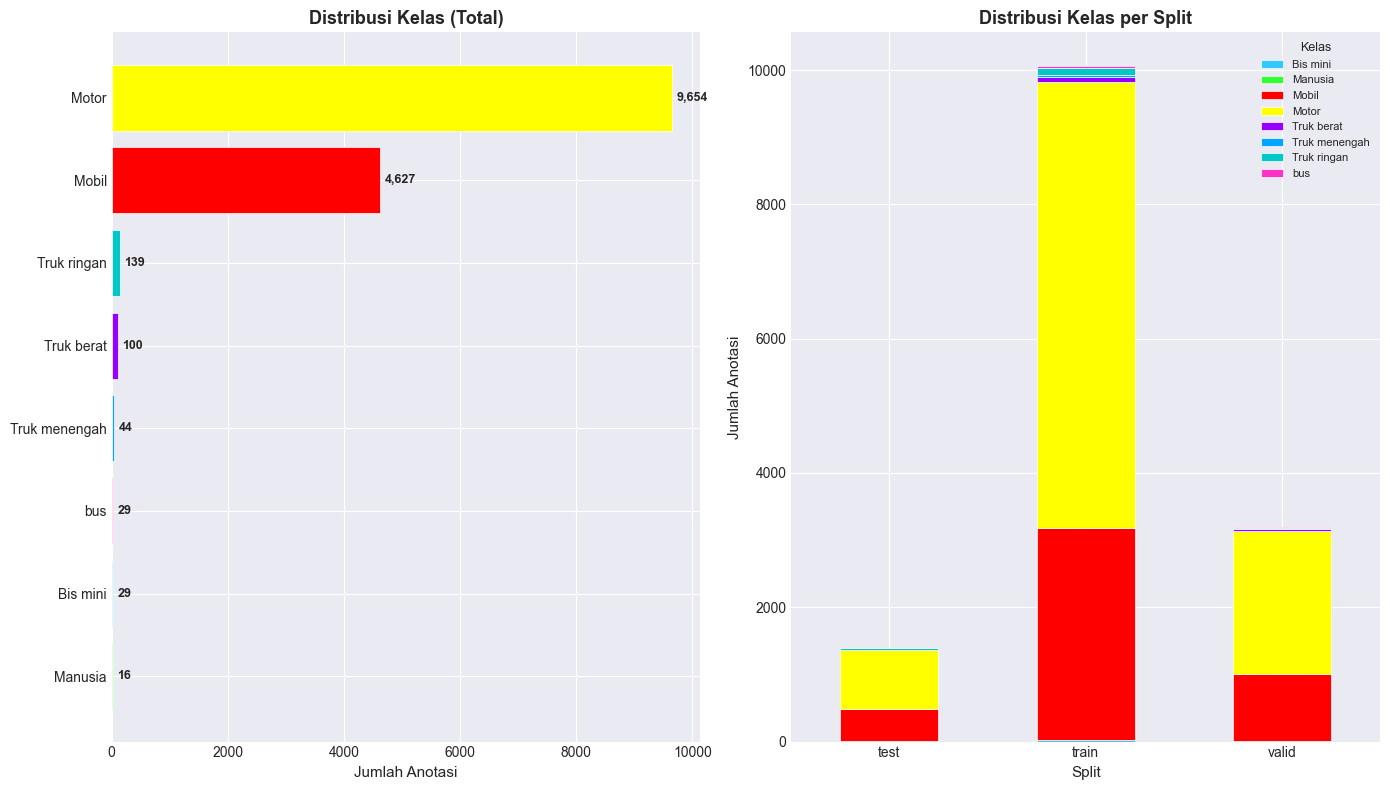

  Disimpan: eda_class_distribution.png

  DISTRIBUSI UKURAN BOUNDING BOX

  Kelas            Width (avg)  Height (avg) Area (avg)  
  ────────────────────────────────────────────────────
  Bis mini         0.1538       0.3238       0.058678    
  Manusia          0.0248       0.1043       0.002902    
  Mobil            0.1310       0.2336       0.035774    
  Motor            0.0382       0.0896       0.004284    
  Truk berat       0.2169       0.4833       0.117591    
  Truk menengah    0.1987       0.4207       0.095716    
  Truk ringan      0.1507       0.3465       0.058842    
  bus              0.2238       0.5031       0.132200    

  Distribusi kategori ukuran:
    Sangat Kecil  :   1999 ( 13.7%)
    Kecil         :   7478 ( 51.1%)
    Sedang        :   3677 ( 25.1%)
    Besar         :   1484 ( 10.1%)

  ⚠️  64.7% objek berukuran kecil/sangat kecil!
      → Pertimbangkan resolusi training yang lebih tinggi (640+)
      → Gunakan mosaic augmentation untuk objek kecil


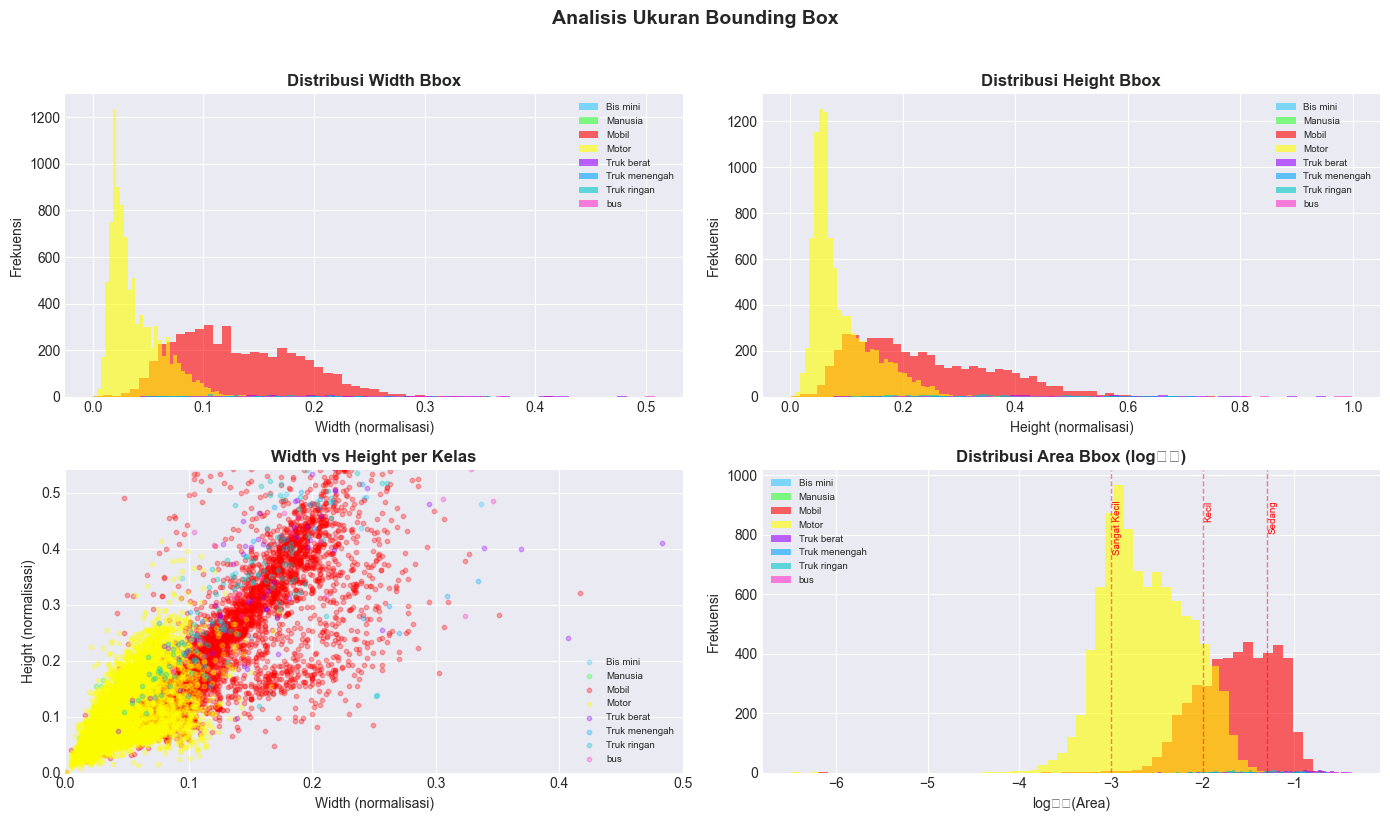

  → Disimpan: eda_bbox_size_distribution.png

  HEATMAP LOKASI OBJEK


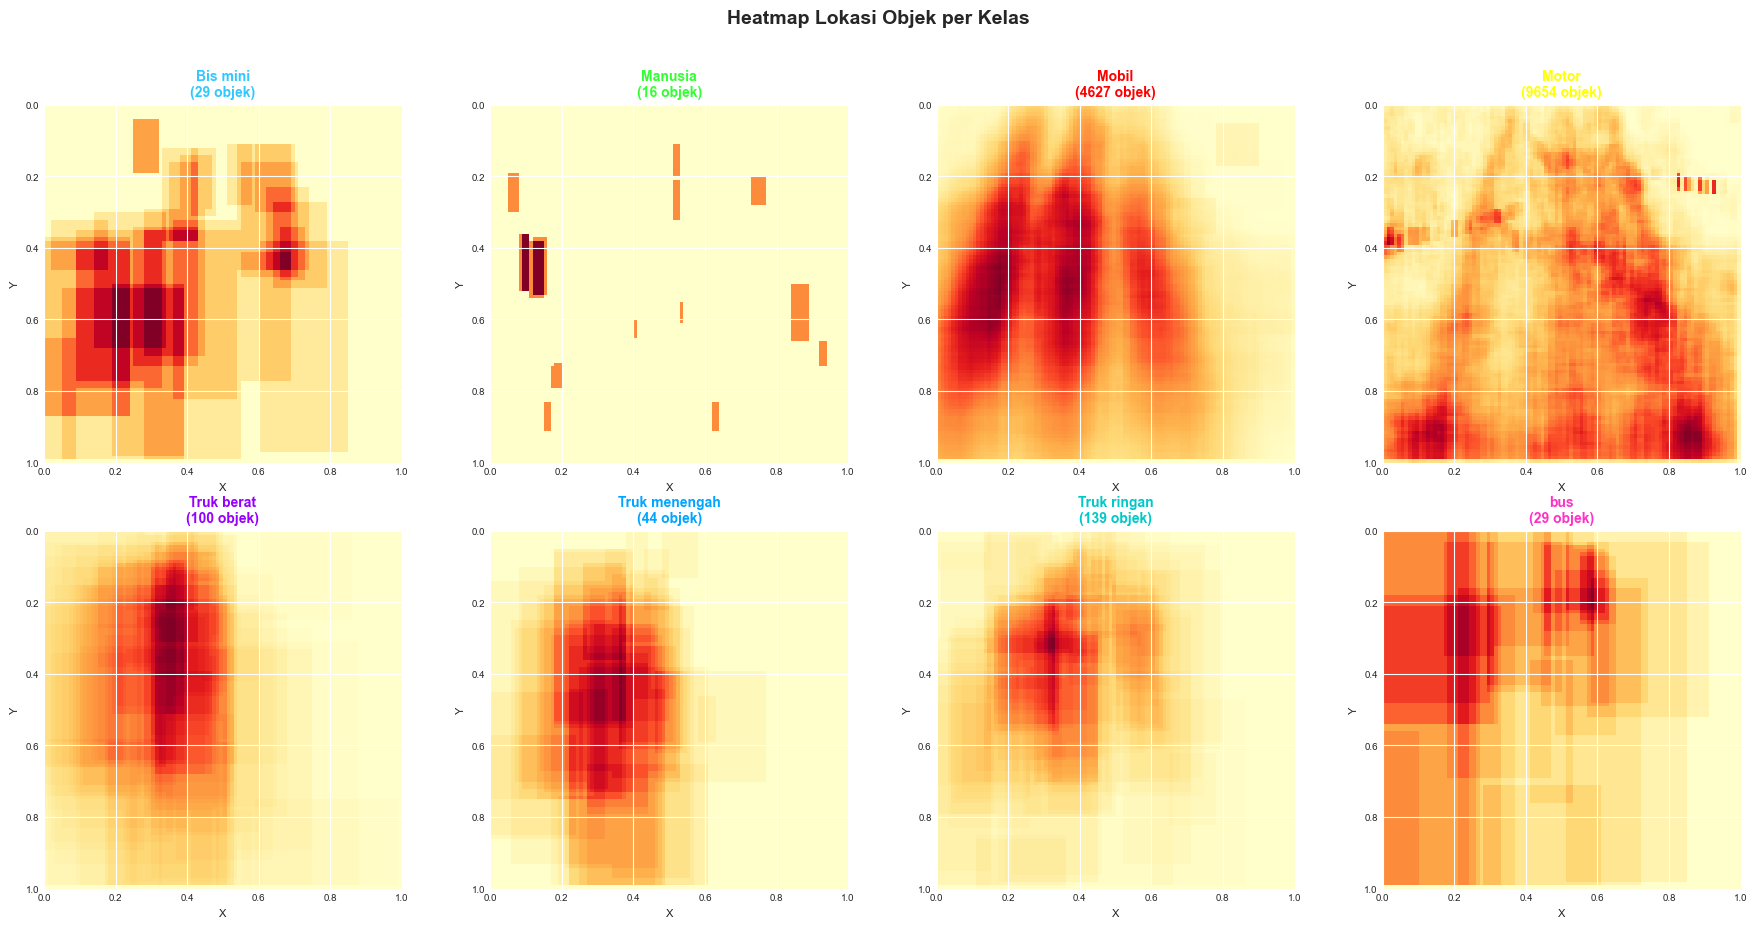

  → Disimpan: eda_bbox_heatmap_per_class.png


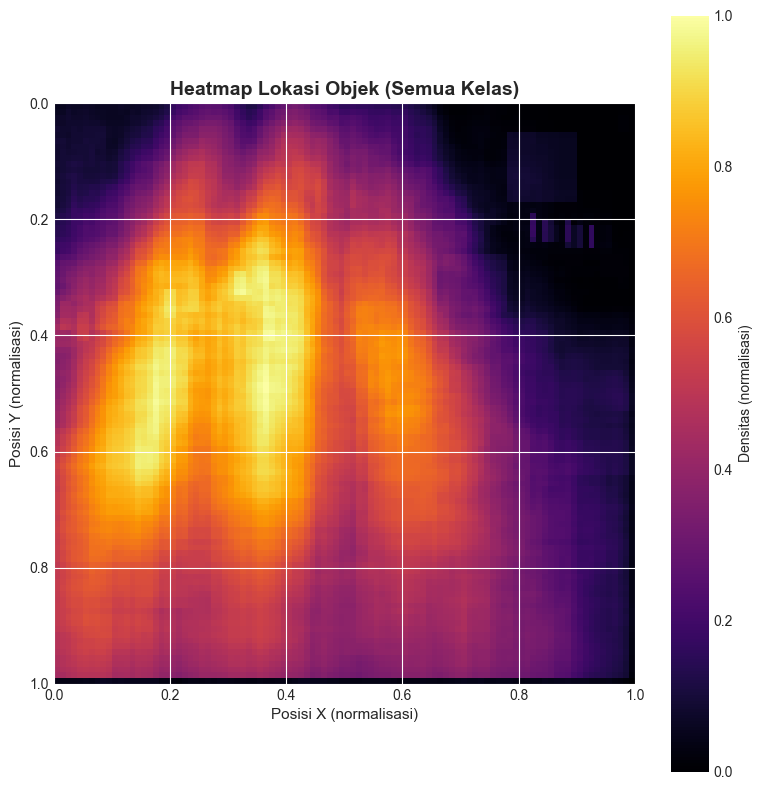

  → Disimpan: eda_bbox_heatmap_all.png

  Rata-rata posisi center X: 0.455 (tengah)
  Rata-rata posisi center Y: 0.427 (atas)

  OVERLAP ANALYSIS (IoU)

  Gambar dianalisis       : 200
  Total pasangan overlap  : 1910

  Statistik IoU (hanya pasangan yang overlap > 0):
    Mean IoU              : 0.0795
    Median IoU            : 0.0402
    Max IoU               : 0.9915
    Std IoU               : 0.1213

  Distribusi IoU:
    [0.0 - 0.1):   1466 ( 76.8%) ██████████████████████████████████████
    [0.1 - 0.3):    349 ( 18.3%) █████████
    [0.3 - 0.5):     56 (  2.9%) █
    [0.5 - 0.7):     25 (  1.3%) 
    [0.7 - 1.0):     14 (  0.7%) 

  Pasangan dengan IoU > 0.5: 39
  ⚠️  Ada 39 pasangan bbox dengan overlap tinggi!
      → Pertimbangkan NMS threshold > 0.5 saat inference
      → Review label yang mungkin duplikat


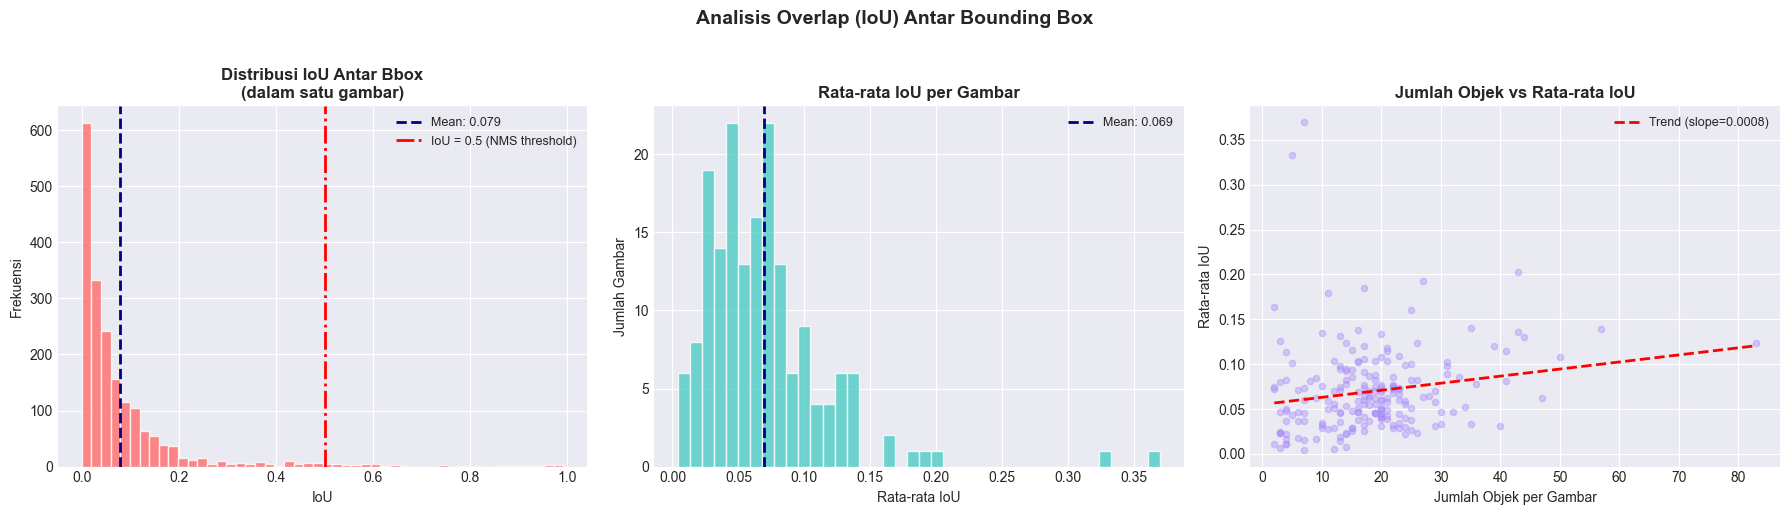


  → Disimpan: eda_overlap_analysis.png

  STATISTIK TAMBAHAN

  Jumlah objek per gambar:
    Min        : 1
    Max        : 113
    Mean       : 17.4
    Median     : 17.0
    Std        : 12.0

  Aspek rasio bbox (width/height):
    Min        : 0.093
    Max        : 4.714
    Mean       : 0.513
    Median     : 0.452


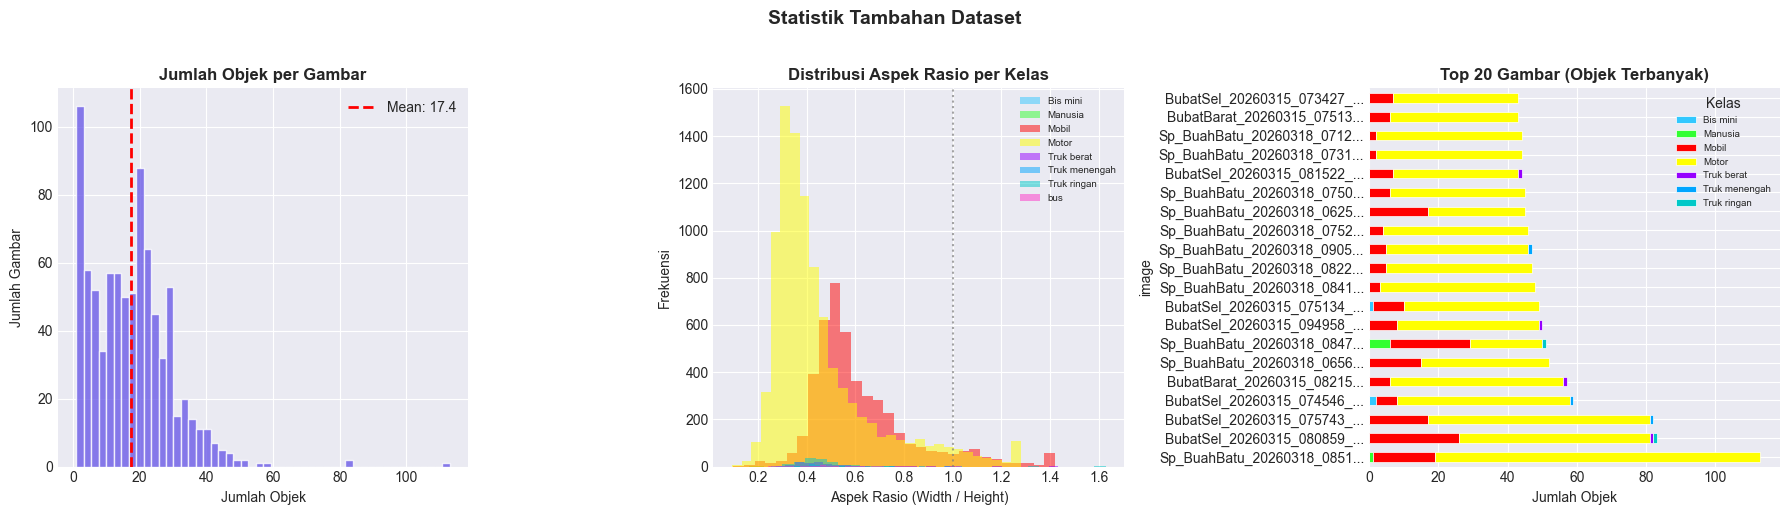


  → Disimpan: eda_additional_stats.png

✅ EDA selesai! Semua grafik telah disimpan di folder dataset.
   Path: d:\Semester 6\Capstone



In [52]:
def main():
    # """
    # Fungsi utama yang menjalankan seluruh pipeline EDA secara berurutan.
    # """
    # print("\n" + "▓" * 65)
    # print("▓  EDA DATASET YOLO — TRAFFIC MONITORING (LALU LINTAS PADAT)   ▓")
    # print("▓  Dataset: Lalu Lintas Buah Batu Bandung                      ▓")
    # print("▓" * 65 + "\n")

    # 1. Load dataset
    df = load_dataset()

    if df.empty:
        print(" Dataset kosong! Periksa path dan format data.")
        return

    # 2. Visualisasi bounding box (sampel acak dari train)
    visualize_bounding_boxes(df, split="train", num_images=NUM_SAMPLE_IMAGES)

    # 3. Distribusi kelas
    class_distribution(df)

    # 4. Distribusi ukuran bounding box
    df = bbox_size_distribution(df)

    # 5. Heatmap lokasi objek
    bbox_heatmap(df)

    # 6. Overlap / IoU analysis
    overlap_analysis(df)

    # 7. Statistik tambahan
    additional_statistics(df)


    print("✅ EDA selesai! Semua grafik telah disimpan di folder dataset.")
    print(f"   Path: {DATASET_ROOT}\n")


if __name__ == "__main__":
    main()
